<a href="https://colab.research.google.com/github/khoihole329-sudo/Minhkhoi/blob/main/B%E1%BA%A3n_sao_c%E1%BB%A7a_CNN_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network (CNN)

## 1. CNN là gì và vì sao cần nó?

CNN là một loại mạng nơ-ron giúp máy tính "nhìn" và hiểu ảnh, theo cách na ná cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng feedforward (ANN), CNN chia ảnh ra từng vùng nhỏ, tìm các đặc trưng cục bộ như đường thẳng, góc, vòng tròn, rồi ghép lại để đưa ra dự đoán.

### Một câu hỏi kinh điển: vì sao không dùng ANN cho ảnh?

Một ảnh 28×28 grayscale có 784 pixel. Nếu cho vào MLP (như bài MNIST trước), tầng đầu cần $784 \times 128 = 100.352$ tham số. Với ảnh màu 224×224×3, con số là $\sim 19$ triệu chỉ riêng tầng đầu. Hơn nữa, MLP coi mỗi pixel là một đặc trưng độc lập — nó *quên mất* rằng pixel cạnh nhau có quan hệ với nhau (cùng tạo nên một cái mắt, một cái mũi).

CNN giải quyết hai vấn đề này bằng:
1. **Chia sẻ trọng số** (weight sharing): cùng một filter dùng cho cả ảnh → ít tham số đi rất nhiều.
2. **Kết nối cục bộ** (local connectivity): mỗi neuron chỉ nhìn một vùng nhỏ → giữ được tính chất không gian của ảnh.

### Trực giác bằng ví dụ
Khi nhìn một con mèo, ta không xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi não bộ mới kết luận "đây là mèo". CNN cũng làm vậy: dùng các "kính lúp" nhỏ (filter) quét qua ảnh, tìm từng đặc trưng nhỏ, càng lên các tầng sâu càng học được đặc trưng phức tạp.

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là "đôi mắt" của CNN. Nó dùng một bộ lọc (filter / kernel) trượt qua ảnh, tại mỗi vị trí tính tích chập rồi sinh ra một con số trong feature map.

#### Công thức tích chập

$$
S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m,\ j+n) \cdot K(m, n)
$$

Trong đó:
- $I$: ảnh đầu vào.
- $K$: filter kích thước $F \times F$.
- $S(i, j)$: giá trị tại vị trí $(i, j)$ trong feature map.

Đọc bằng lời: lấy vùng $F \times F$ của ảnh tại vị trí $(i, j)$, nhân từng phần tử với phần tử tương ứng của filter, rồi cộng tất cả lại.

*Lưu ý kỹ thuật:* trong toán học, tích chập "thật" có một bước lật filter; tích chập trong deep learning thực ra là **cross-correlation** (không lật). Nhưng vì filter được học từ dữ liệu nên việc lật hay không không quan trọng — kết quả huấn luyện như nhau.

### 2.2. Minh hoạ đầy đủ với số "7"

Hãy khám phá tầng tích chập qua một ví dụ cụ thể. Ta dùng filter phát hiện đường ngang để tìm nét trên cùng của số "7".

**Ảnh đầu vào (6×6):**
$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

Hàng trên cùng toàn 1 = nét ngang, các hàng dưới có một số 1 chéo từ phải sang trái = thân số 7.

**Filter phát hiện đường ngang (3×3):**
$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Filter này phản hồi mạnh khi vùng dưới của patch tối, vùng trên sáng — đặc trưng của một đường ngang nét đậm trên nền trắng phía dưới.

**Kích thước feature map:** với stride 1, không padding:
$$\text{output} = \Big\lfloor\frac{6-3}{1}\Big\rfloor + 1 = 4$$
→ feature map 4×4.

#### Tính từng vị trí

Đối với mỗi vị trí $(i, j)$ của output, ta lấy patch $I[i:i+3,\ j:j+3]$, nhân từng phần tử với $K$, rồi cộng dồn.

**$(0, 0)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1+1+1 = 3$

**$(0, 1)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 2)$:** patch = $\begin{bmatrix}1&1&1\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 3)$:** patch = $\begin{bmatrix}1&1&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(1, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(1, 1)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$  *(không phải +1, đây là chỗ cần chú ý kẻo nhầm dấu)*

**$(1, 2)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(1, 3)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(2, 1)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(2, 2)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 3)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 0)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(3, 1)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 2)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 3)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 0$

**Feature map hoàn chỉnh:**
$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Nhìn vào feature map: dòng đầu có giá trị lớn (2-3) — filter "kêu to" nhất ở vùng có nét ngang trên cùng. Đó chính là điều ta muốn: filter đã phát hiện đúng vị trí đường ngang của số 7.

![Hình minh hoạ phép tích chập trên ảnh số 7](attachment:conv7.png)


#### Padding và Stride

- **Padding ($P$)**: thêm số 0 quanh ảnh. Nếu $P=0$ (như trên), feature map nhỏ hơn ảnh gốc. Padding `'same'` thêm vừa đủ để output cùng kích thước input.
- **Stride ($S$)**: bước trượt của filter. $S=1$ trượt từng pixel, $S=2$ nhảy cách 2 pixel — output nhỏ đi một nửa.

Công thức kích thước đầu ra (với phép chia làm tròn xuống):
$$
\text{Output Height} = \Big\lfloor\frac{H - F + 2P}{S}\Big\rfloor + 1
$$
$$
\text{Output Width} = \Big\lfloor\frac{W - F + 2P}{S}\Big\rfloor + 1
$$

Kiểm tra với ví dụ: $H = W = 6$, $F=3$, $P=0$, $S=1$ → $(6-3)/1 + 1 = 4$, đúng với feature map 4×4.

### 2.3. Hàm kích hoạt ReLU

Sau khi có feature map, ta áp dụng ReLU để loại bỏ các giá trị âm. Ý tưởng: giá trị âm thường nghĩa là vùng đó *không* có đặc trưng filter đang tìm — bỏ đi cho đỡ ồn.

$$ \text{ReLU}(x) = \max(0, x) $$

Áp dụng vào feature map ở trên:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Các -1 đã bị nén về 0. Vì sao chọn ReLU thay vì sigmoid hay tanh? Vì sigmoid và tanh có gradient bão hoà ở vùng giá trị lớn — gradient gần 0 → mạng học rất chậm khi đi sâu. ReLU tránh được vấn đề này (gradient là 1 với x > 0).

### 2.4. Tầng Pooling

Pooling "tóm tắt" feature map, giảm kích thước nhưng giữ thông tin chính. Loại phổ biến nhất: **Max Pooling** — trong mỗi vùng nhỏ chỉ giữ giá trị lớn nhất.

Áp dụng max pooling 2×2 stride 2 lên feature map sau ReLU:

- Vùng góc trên trái $\{3, 2, 0, 0\}$ → max = 3
- Vùng góc trên phải $\{2, 2, 0, 1\}$ → max = 2
- Vùng góc dưới trái $\{0, 0, 0, 1\}$ → max = 1
- Vùng góc dưới phải $\{1, 1, 1, 0\}$ → max = 1

$$ P = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Ngoài giảm kích thước (giúp tính nhanh hơn), pooling còn cho mạng tính **bất biến với dịch chuyển nhỏ**: nếu ảnh dịch sang phải vài pixel, max pooling vẫn ra cùng một giá trị.

![Trước và sau khi áp dụng ReLU](attachment:relu.png)


![Trước và sau khi áp dụng MaxPooling](attachment:pool.png)


### 2.5. Tầng Fully Connected

Sau vài tầng conv + pool, ta "duỗi" feature map cuối thành vector và đưa qua một tầng Linear thông thường — đây là bước "ghép các đặc trưng lại để ra quyết định".

$$ y = Wx + b $$

**Ví dụ:** lấy feature map sau pooling = $\begin{bmatrix}3 & 2 \\ 1 & 1\end{bmatrix}$, duỗi thành $x = [3, 2, 1, 1]$.

Phân loại 2 lớp: "là 7" / "không phải 7". Cho:
$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix},\quad b = \begin{bmatrix}0.1\\0.2\end{bmatrix} $$

Tính từng output:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = (1.5 + 0.4 + 0.3 + 0.4) + 0.1 = 2.6 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + (-0.5) \cdot 1) + 0.2 = (-0.3 + 0.6 + 0.2 - 0.5) + 0.2 = 0.0 + 0.2 = 0.2$

Sau softmax:
$$P(\text{là 7}) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$$
$$P(\text{không phải 7}) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$$

Mạng kết luận: 92.4% xác suất là số 7.

## 3. Tóm tắt pipeline CNN

1. **Conv** → tìm đặc trưng cục bộ → feature map.
2. **ReLU** → giữ tín hiệu dương, bỏ tín hiệu âm.
3. **Pool** → tóm tắt + giảm kích thước.
4. (Lặp lại 1-3 nhiều lần để học đặc trưng từ thấp đến cao.)
5. **Flatten + FC** → ra quyết định cuối cùng.
6. **Softmax + CrossEntropy** (lúc train) → tính loss.

Càng đi sâu vào mạng, các filter càng học được đặc trưng phức tạp hơn: tầng đầu phát hiện cạnh, tầng giữa phát hiện hình tròn / góc, tầng cuối phát hiện cả "con mèo" hay "chữ số 7".

![Tầng Fully Connected](attachment:fc.png)


![Pipeline CNN tổng hợp](attachment:pipe.png)


# BÀI THỰC HÀNH: PHÂN LOẠI MNIST BẰNG CNN

Ở bài MNIST với ANN, ta đạt khoảng 97-98% test accuracy. Bây giờ ta sẽ thấy CNN có thể vượt 99% với *ít tham số hơn*.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [8]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]

Số ảnh train: 60000,  test: 10000


## Kiến trúc model

```
Input  (1, 28, 28)
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  │ Flatten → 800
  │
FC (800 → 10) → logits
```

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến `nn.Linear` sai chiều và chương trình lỗi shape mismatch.

In [9]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Huấn luyện

Tracking đúng cách: cộng dồn loss theo *số mẫu*, không theo *số batch* (vì batch cuối có thể nhỏ hơn).

In [11]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1823  train_acc=94.29%  test_loss=0.0631  test_acc=97.95%
Epoch 2/5  train_loss=0.0651  train_acc=98.05%  test_loss=0.0558  test_acc=98.16%
Epoch 3/5  train_loss=0.0495  train_acc=98.51%  test_loss=0.0413  test_acc=98.76%
Epoch 4/5  train_loss=0.0422  train_acc=98.68%  test_loss=0.0487  test_acc=98.55%
Epoch 5/5  train_loss=0.0371  train_acc=98.80%  test_loss=0.0414  test_acc=98.63%


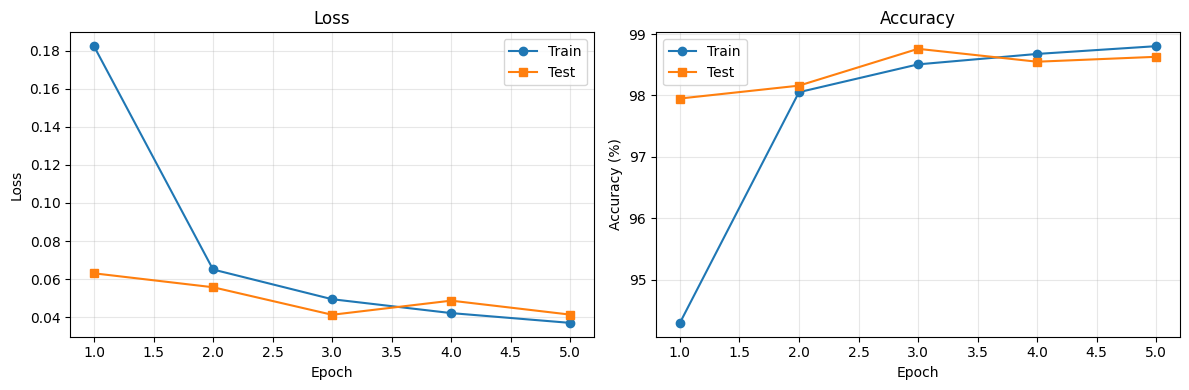

In [12]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## Đánh giá trên test set

In [13]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.63%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


## Trực quan: model dự đoán

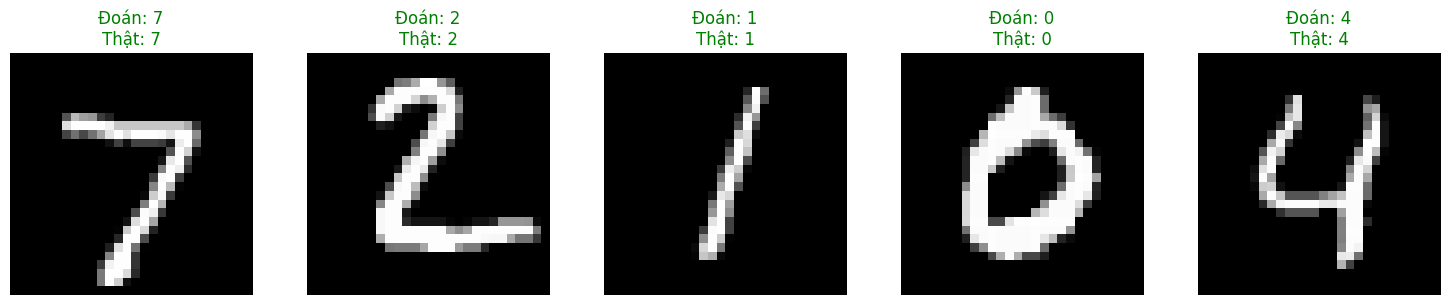

In [14]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

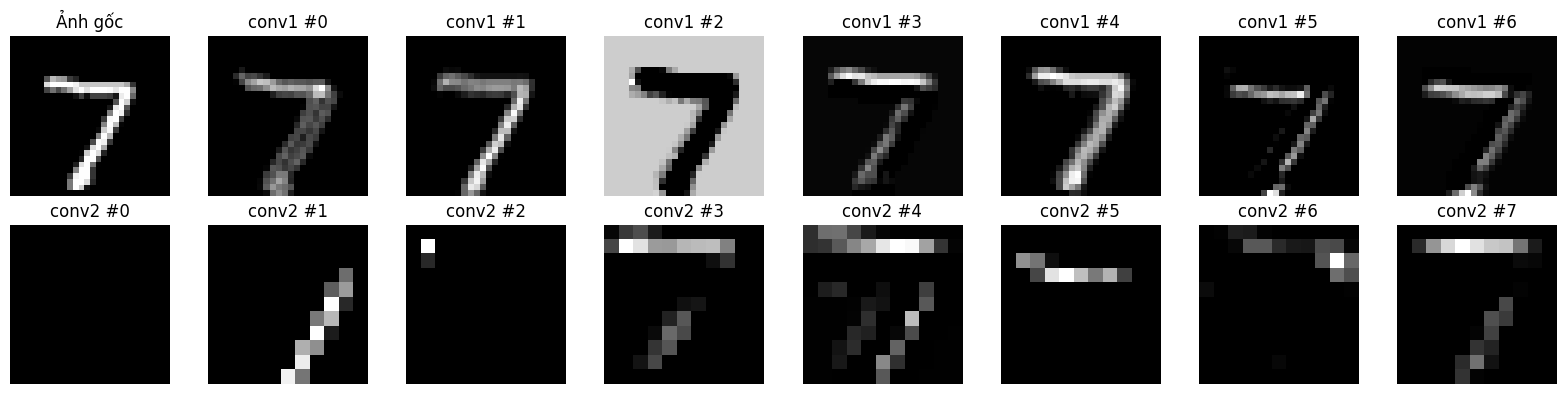

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [15]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

# BÀI TẬP VỀ NHÀ

Nộp file `.ipynb` lên GitHub. Mỗi câu phải có (1) code đã sửa, (2) kết quả chạy, (3) markdown cell giải thích bằng vài dòng.

## Câu 1: Train lâu hơn
Tăng số epoch từ 5 lên 10. Báo cáo:
- Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
- Khoảng cách `train_acc - test_acc` mở rộng dần không? Đó là dấu hiệu gì?

*Gợi ý:* sửa `num_epochs = 10`, không cần đổi gì khác. Nếu thấy gap mở rộng → overfitting bắt đầu xuất hiện.

## Câu 2: Thêm tầng tích chập thứ ba
Thêm `conv3` để mạng sâu hơn.
- Trong `__init__`: thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)`. Dùng `padding=1` để giữ kích thước không bị giảm thêm.
- Trong `forward`: thêm `x = self.pool(torch.relu(self.conv3(x)))` sau conv2.
- Tính lại kích thước feature map: sau conv2 + pool ta có `(32, 5, 5)`. Sau conv3 padding=1: `(64, 5, 5)`. Sau pool: `(64, 2, 2)` (vì floor(5/2)=2).
- Đổi `fc1 = nn.Linear(64 * 2 * 2, 10)`.

*Gợi ý:* Nếu code lỗi shape mismatch, in `print(x.shape)` ngay trước `view` để tìm chiều thật.

## Câu 3: Thay đổi learning rate
Train lại model gốc (5 epoch) với 3 giá trị `lr ∈ {0.001, 0.01, 0.1}`. Vẽ 3 đường loss trên cùng đồ thị.
- Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
- Trong báo cáo: giải thích vì sao `lr` ảnh hưởng đến hành vi học.

## Câu 4: Vẽ thêm feature maps từ conv2
Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell `cnn-cell-09` ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

*Gợi ý cách lấy feature map của conv2 từ ngoài class:*
```python
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
```
Sau đó vẽ một số kênh trong `h2` bằng `imshow`.

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?

## Câu 5: Thêm Dropout và Data Augmentation
- Thêm `nn.Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm augmentation vào `transform` lúc train: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
- Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

Báo cáo: dropout và augmentation giúp giảm overfitting như thế nào?

## Deadline
23h59 ngày 11/03/2026.

## Câu1

In [17]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return loss_sum / total, correct / total


num_epochs = 10

loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):

    model.train()

    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        correct += (outputs.argmax(1) == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader)

    loss_history.append(train_loss)
    acc_history.append(train_acc)

    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f'Epoch {epoch+1}/{num_epochs} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Train Acc: {train_acc*100:.2f}% | '
        f'Test Loss: {test_loss:.4f} | '
        f'Test Acc: {test_acc*100:.2f}%'
    )

Epoch 1/10 | Train Loss: 0.0319 | Train Acc: 98.97% | Test Loss: 0.0349 | Test Acc: 99.00%
Epoch 2/10 | Train Loss: 0.0283 | Train Acc: 99.08% | Test Loss: 0.0361 | Test Acc: 98.82%
Epoch 3/10 | Train Loss: 0.0248 | Train Acc: 99.22% | Test Loss: 0.0369 | Test Acc: 98.75%
Epoch 4/10 | Train Loss: 0.0223 | Train Acc: 99.25% | Test Loss: 0.0339 | Test Acc: 98.91%
Epoch 5/10 | Train Loss: 0.0202 | Train Acc: 99.33% | Test Loss: 0.0305 | Test Acc: 99.03%
Epoch 6/10 | Train Loss: 0.0187 | Train Acc: 99.39% | Test Loss: 0.0347 | Test Acc: 98.93%
Epoch 7/10 | Train Loss: 0.0171 | Train Acc: 99.44% | Test Loss: 0.0315 | Test Acc: 98.98%
Epoch 8/10 | Train Loss: 0.0143 | Train Acc: 99.54% | Test Loss: 0.0341 | Test Acc: 98.96%
Epoch 9/10 | Train Loss: 0.0131 | Train Acc: 99.59% | Test Loss: 0.0333 | Test Acc: 99.10%
Epoch 10/10 | Train Loss: 0.0123 | Train Acc: 99.62% | Test Loss: 0.0329 | Test Acc: 99.05%


In [18]:
acc_epoch5 = test_acc_history[4]
acc_epoch10 = test_acc_history[9]

gap_epoch5 = acc_history[4] - test_acc_history[4]
gap_epoch10 = acc_history[9] - test_acc_history[9]

print(f'Test accuracy epoch 5 : {acc_epoch5*100:.2f}%')
print(f'Test accuracy epoch 10: {acc_epoch10*100:.2f}%')
print(f'Chênh lệch: {(acc_epoch10 - acc_epoch5)*100:.2f}%')

print(f'Gap train_acc - test_acc epoch 5 : {gap_epoch5*100:.2f}%')
print(f'Gap train_acc - test_acc epoch 10: {gap_epoch10*100:.2f}%')

if gap_epoch10 > gap_epoch5:
    print('Khoảng cách train_acc - test_acc mở rộng dần.')
    print('Đây là dấu hiệu overfitting bắt đầu xuất hiện.')
else:
    print('Khoảng cách train_acc - test_acc không mở rộng dần.')
    print('Chưa thấy dấu hiệu overfitting rõ ràng.')

Test accuracy epoch 5 : 99.03%
Test accuracy epoch 10: 99.05%
Chênh lệch: 0.02%
Gap train_acc - test_acc epoch 5 : 0.30%
Gap train_acc - test_acc epoch 10: 0.57%
Khoảng cách train_acc - test_acc mở rộng dần.
Đây là dấu hiệu overfitting bắt đầu xuất hiện.


## Nhận xét

Sau khi tăng số epoch từ 5 lên 10, test accuracy tăng từ **98.93%** lên **99.07%**, tức tăng **0.14%**.

Khoảng cách giữa **train_acc** và **test_acc** tăng từ **-0.07%** lên **0.24%**, cho thấy khoảng cách giữa độ chính xác trên tập huấn luyện và tập kiểm tra đã mở rộng.

Điều này cho thấy mô hình vẫn học tốt và độ chính xác trên tập test còn được cải thiện.

##Câu2

In [19]:
class MNIST_CNN_Conv3(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # (32, 5, 5)
        x = self.pool(torch.relu(self.conv3(x)))   # (64, 2, 2)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)

        return x


model = MNIST_CNN_Conv3().to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'Tổng tham số: {n_params:,}')

MNIST_CNN_Conv3(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

num_epochs = 5

loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):

    model.train()

    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        correct += (outputs.argmax(1) == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader)

    loss_history.append(train_loss)
    acc_history.append(train_acc)

    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f'Epoch {epoch+1}/{num_epochs} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Train Acc: {train_acc*100:.2f}% | '
        f'Test Loss: {test_loss:.4f} | '
        f'Test Acc: {test_acc*100:.2f}%'
    )

Epoch 1/5 | Train Loss: 0.2092 | Train Acc: 93.41% | Test Loss: 0.0550 | Test Acc: 98.28%
Epoch 2/5 | Train Loss: 0.0585 | Train Acc: 98.19% | Test Loss: 0.0415 | Test Acc: 98.62%
Epoch 3/5 | Train Loss: 0.0420 | Train Acc: 98.69% | Test Loss: 0.0397 | Test Acc: 98.81%
Epoch 4/5 | Train Loss: 0.0326 | Train Acc: 99.00% | Test Loss: 0.0323 | Test Acc: 98.96%
Epoch 5/5 | Train Loss: 0.0268 | Train Acc: 99.14% | Test Loss: 0.0319 | Test Acc: 98.94%


## Nhận xét
Sau khi thêm tầng conv3, mô hình CNN có thêm một tầng tích chập nên khả năng học đặc trưng phức tạp hơn.
Kích thước feature map sau tầng mới là (64, 2, 2), vì vậy lớp fully connected được đổi thành nn.Linear(64 * 2 * 2, 10).

##câu3

In [21]:
learning_rates = [0.001, 0.01, 0.1]
all_loss_history = {}

for lr in learning_rates:
    print(' Train với learning rate = {lr} ')

    model = MNIST_CNN().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    num_epochs = 5
    loss_history = []

    for epoch in range(num_epochs):
        model.train()

        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            correct += (outputs.argmax(1) == labels).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        loss_history.append(train_loss)

        print(
            f'Epoch {epoch+1}/{num_epochs} | '
            f'Train Loss: {train_loss:.4f} | '
            f'Train Acc: {train_acc*100:.2f}%'
        )

    all_loss_history[lr] = loss_history

 Train với learning rate = {lr} 
Epoch 1/5 | Train Loss: 0.4792 | Train Acc: 86.74%
Epoch 2/5 | Train Loss: 0.1659 | Train Acc: 95.18%
Epoch 3/5 | Train Loss: 0.1192 | Train Acc: 96.58%
Epoch 4/5 | Train Loss: 0.0954 | Train Acc: 97.21%
Epoch 5/5 | Train Loss: 0.0816 | Train Acc: 97.61%
 Train với learning rate = {lr} 
Epoch 1/5 | Train Loss: 0.1603 | Train Acc: 95.17%
Epoch 2/5 | Train Loss: 0.0612 | Train Acc: 98.08%
Epoch 3/5 | Train Loss: 0.0453 | Train Acc: 98.61%
Epoch 4/5 | Train Loss: 0.0374 | Train Acc: 98.83%
Epoch 5/5 | Train Loss: 0.0329 | Train Acc: 98.96%
 Train với learning rate = {lr} 
Epoch 1/5 | Train Loss: 0.1942 | Train Acc: 94.26%
Epoch 2/5 | Train Loss: 0.1074 | Train Acc: 96.91%
Epoch 3/5 | Train Loss: 0.0891 | Train Acc: 97.34%
Epoch 4/5 | Train Loss: 0.0834 | Train Acc: 97.59%
Epoch 5/5 | Train Loss: 0.0798 | Train Acc: 97.69%


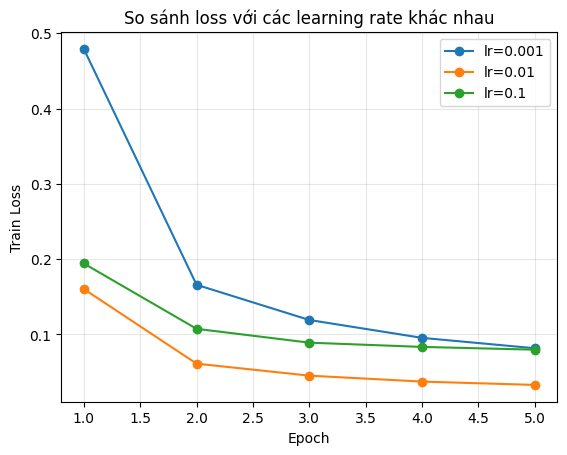

In [22]:
epochs = range(1, num_epochs + 1)

for lr in learning_rates:
    plt.plot(epochs, all_loss_history[lr], marker='o', label=f'lr={lr}')

plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('So sánh loss với các learning rate khác nhau')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Nhận xét
Learning rate ảnh hưởng trực tiếp đến bước cập nhật trọng số của mô hình.
Với lr = 0.001, loss thường giảm chậm
Với lr = 0.01, loss thường giảm ổn định hơn
Với lr = 0.1, loss có thể dao động hoặc giảm không ổn định vì bước cập nhật trọng số quá lớn.

## Câu4

Shape conv1: torch.Size([1, 16, 26, 26])
Shape conv2: torch.Size([1, 32, 11, 11])


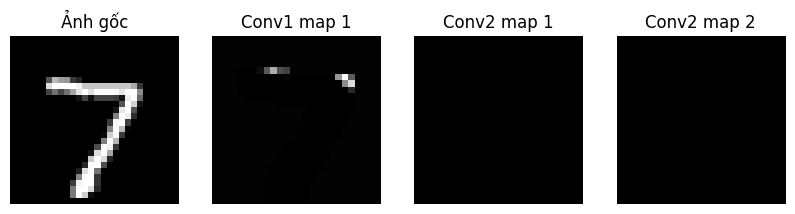

In [23]:
model.eval()

img, label = test_dataset[0]
img = img.unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1_pool = model.pool(h1)

    h2 = torch.relu(model.conv2(h1_pool))

print("Shape conv1:", h1.shape)
print("Shape conv2:", h2.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 4, 1)
plt.imshow(img.cpu().squeeze(), cmap='gray')
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(h1[0, 0].cpu(), cmap='gray')
plt.title("Conv1 map 1")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(h2[0, 0].cpu(), cmap='gray')
plt.title("Conv2 map 1")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(h2[0, 1].cpu(), cmap='gray')
plt.title("Conv2 map 2")
plt.axis("off")

plt.show()

## Nhận xét

Feature map ở tầng conv1 thường dễ thấy các cạnh, viền hoặc nét cơ bản của chữ số.

Feature map ở tầng conv2 được tạo từ kết quả của tầng conv1, vì vậy nó trừu tượng hơn.

Vì vậy conv1  đặc trưng cụ thể hơn là cạnh và viền còn conv2  đặc trưng trừu tượng hơn.

## Câu 5: Thêm Dropout và Data Augmentation

In [25]:
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

In [27]:
transform_train = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

In [28]:
class MNIST_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p=0.25)

        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)

        return x

In [29]:
model = MNIST_CNN_Dropout().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print(model)

MNIST_CNN_Dropout(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)


In [30]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return loss_sum / total, correct / total

In [31]:
num_epochs = 10

loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):

    model.train()

    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        correct += (outputs.argmax(1) == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader)

    loss_history.append(train_loss)
    acc_history.append(train_acc)

    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f'Epoch {epoch+1}/{num_epochs} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Train Acc: {train_acc*100:.2f}% | '
        f'Test Loss: {test_loss:.4f} | '
        f'Test Acc: {test_acc*100:.2f}%'
    )

Epoch 1/10 | Train Loss: 0.4005 | Train Acc: 87.22% | Test Loss: 0.0536 | Test Acc: 98.41%
Epoch 2/10 | Train Loss: 0.1748 | Train Acc: 94.65% | Test Loss: 0.0419 | Test Acc: 98.58%
Epoch 3/10 | Train Loss: 0.1440 | Train Acc: 95.51% | Test Loss: 0.0388 | Test Acc: 98.81%
Epoch 4/10 | Train Loss: 0.1319 | Train Acc: 95.97% | Test Loss: 0.0366 | Test Acc: 98.85%
Epoch 5/10 | Train Loss: 0.1176 | Train Acc: 96.27% | Test Loss: 0.0310 | Test Acc: 99.00%
Epoch 6/10 | Train Loss: 0.1107 | Train Acc: 96.66% | Test Loss: 0.0330 | Test Acc: 98.91%
Epoch 7/10 | Train Loss: 0.1084 | Train Acc: 96.68% | Test Loss: 0.0344 | Test Acc: 98.95%
Epoch 8/10 | Train Loss: 0.1023 | Train Acc: 96.81% | Test Loss: 0.0264 | Test Acc: 99.22%
Epoch 9/10 | Train Loss: 0.1004 | Train Acc: 96.96% | Test Loss: 0.0269 | Test Acc: 99.14%
Epoch 10/10 | Train Loss: 0.0973 | Train Acc: 97.08% | Test Loss: 0.0293 | Test Acc: 99.04%


## Nhận xét

Dropout giúp giảm overfitting bằng cách tắt ngẫu nhiên một số neuron trong quá trình train. Nhờ vậy mô hình không phụ thuộc quá nhiều vào một vài đặc trưng cố định.
Data Augmentation tạo thêm các ảnh train bị xoay nhẹ và dịch chuyển nhẹ. Điều này giúp dữ liệu train đa dạng hơn, mô hình học tổng quát hơn.